In [1]:
import pandas as pd
import sklearn

In [7]:
df = pd.read_csv("numeric_prop_census_isd.csv")
df.drop(columns=["json_mhl_housing_5year", "json_bldg_mhl_housing_5year", "rs_prop_yr_remod", "rs_prop_living_area"], inplace=True)
def years_since(x):
  return 2026-x
yr_built_correct = df['rs_prop_yr_built'].map(years_since)
df.insert(1, 'rs_prop_yrs_since_built',yr_built_correct)
df = df.drop(columns=['rs_prop_yr_built', "rs_prop_sam_id", ])
for column_name in df:
  df[column_name].fillna(df[column_name].mean(),inplace=True)


df.info(verbose=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315293 entries, 0 to 315292
Data columns (total 47 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   rs_prop_yrs_since_built                        315293 non-null  int64  
 1   Housing_Vehicles_share_no_vehicles             315293 non-null  float64
 2   Housing_LivingArrangements_household_pop       315293 non-null  float64
 3   Housing_LivingArrangements_group_quarters      315293 non-null  float64
 4   Housing_LivingArrangements_avg_hh_size         315293 non-null  float64
 5   Housing_Tenure_owner                           315293 non-null  float64
 6   Housing_Units_total                            315293 non-null  float64
 7   Housing_Units_vacancy_rate                     315293 non-null  float64
 8   Housing_Units_units_per_acre                   315293 non-null  float64
 9   Labor_Commute_share_worked_from_home 

C:\Users\shohi\AppData\Local\Temp\ipykernel_33328\2698776156.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column_name].fillna(df[column_name].mean(),inplace=True)


In [10]:
X = df.drop(columns=["violation_count"])
y = df["violation_count"]
Xtrain, Xtest, ytrain, ytest = sklearn.model_selection.train_test_split(X, y, test_size=0.2)
# come back and do stratification if it's not going great
Xtrain.shape
type(Xtrain)

pandas.core.frame.DataFrame

In [44]:
for depth in range(1, 20):
    treereg = sklearn.tree.DecisionTreeRegressor(max_depth=depth)
    treereg.fit(Xtrain, ytrain)
    print(depth, treereg.score(Xtest, ytest))

1 0.055277794767855215
2 0.09456553198511686
3 0.17015938346143333
4 0.24370730197376134
5 0.329864938376246
6 0.38982220172217674
7 0.4275099538406071
8 0.4796764547755219
9 0.5094607861354248
10 0.5514940280379745
11 0.5773333055541925
12 0.5904847916968057
13 0.6198521860581749
14 0.6347555472605408
15 0.6520604056226361
16 0.6656587115112351
17 0.672729602172508
18 0.6794630856033286
19 0.6872169362017362


In [32]:
ypred = treereg.predict(Xtest)

[Text(0.5, 0.9, 'rs_prop_living_area <= 52810.0\nsquared_error = 7.601\nsamples = 252234\nvalue = 1.242'),
 Text(0.25, 0.7, 'Housing_LivingArrangements_avg_hh_size <= 1.946\nsquared_error = 5.505\nsamples = 228067\nvalue = 1.03'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Population_Age_35_to_54 <= 972.856\nsquared_error = 10.265\nsamples = 54647\nvalue = 1.862'),
 Text(0.0625, 0.3, 'Population_Nativity_share_foreign_born <= 0.381\nsquared_error = 6.59\nsamples = 51367\nvalue = 1.555'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'rs_prop_yrs_since_built <= 104.5\nsquared_error = 43.269\nsamples = 3280\nvalue = 6.665'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Labor_LaborForce_female_participation_rate <= 0.432\nsquared_error = 3.719\nsamples = 173420\nvalue = 0.768'),
 Text(0.3125, 0.3, 'rs_prop_yrs_since_built <= 43.5\nsquared_error = 50.837\nsamples = 809\nvalue = 4.265'),


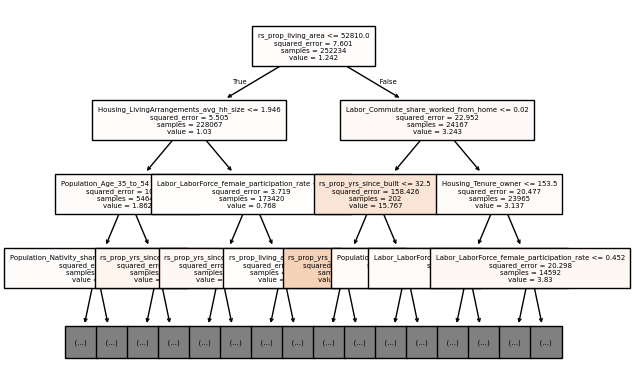

In [33]:
sklearn.tree.plot_tree(treereg, feature_names= X.columns, max_depth=3, filled=True, fontsize=5)

In [16]:
treereg.score(Xtest, ytest)

0.6768452327240105

In [31]:
!pip install dtreeviz
from dtreeviz import dtreeviz
import graphviz

viz = dtreeviz(treereg, Xtrain, ytrain, target_name = 'violation count', feature_names = X.columns, title="Violation count regression", fontname='Arial', colors = {"title":"purple"}, scale = 1.5, X=X.iloc[0].values)

viz.view()

/tmp/ipykernel_4383/2246339879.py:5: DeprecationWarning: dtreeviz() function is deprecated starting from version 2.0. 
 For the same functionality, please use this code instead: 
 m = dtreeviz.model(...) 
 m.view()


TypeError: 'int' object is not subscriptable

In [11]:
cytrain = ytrain.map(lambda x: x>0)
cytest = ytest.map(lambda x: x>0)
for depth in range(1, 20):
    treeclass = sklearn.tree.DecisionTreeClassifier(max_depth=depth)
    treeclass.fit(Xtrain, cytrain)
    # treeclass.score(Xtest, cytest)
    print(depth, treeclass.score(Xtest, cytest))

1 0.6303461837326948
2 0.6441586450784186
3 0.6495821373634215
4 0.6526744794557477
5 0.6621576618722149
6 0.6717042769469862
7 0.6829001411376647
8 0.688989676334861
9 0.6981715536243835
10 0.707353430913906
11 0.7155203856705625
12 0.7227992832109612
13 0.7295707194849268
14 0.7357712618341553
15 0.7416229245627111
16 0.7463803739355207
17 0.7500911844463122
18 0.7545949031859053
19 0.7586545933173694


In [14]:
treeclass = sklearn.tree.DecisionTreeClassifier(max_depth=3)
treeclass.fit(Xtrain, cytrain)
# treeclass.score(Xtest, cytest)
print(depth, treeclass.score(Xtest, cytest))
treeclass.score(Xtest, cytest)

19 0.6495821373634215


0.6495821373634215

[Text(0.5, 0.875, 'Housing_LivingArrangements_avg_hh_size <= 2.057\ngini = 0.481\nsamples = 252234\nvalue = [150772, 101462]'),
 Text(0.25, 0.625, 'rs_prop_yrs_since_built <= 65.5\ngini = 0.496\nsamples = 85692\nvalue = [39082, 46610]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'rs_prop_yrs_since_built <= 42.5\ngini = 0.47\nsamples = 44525\nvalue = [16797, 27728]'),
 Text(0.0625, 0.125, 'gini = 0.485\nsamples = 37301\nvalue = [15411, 21890]'),
 Text(0.1875, 0.125, 'gini = 0.31\nsamples = 7224\nvalue = [1386, 5838]'),
 Text(0.375, 0.375, 'Population_Race_share_non_white <= 0.483\ngini = 0.497\nsamples = 41167\nvalue = [22285, 18882]'),
 Text(0.3125, 0.125, 'gini = 0.489\nsamples = 31696\nvalue = [18209, 13487]'),
 Text(0.4375, 0.125, 'gini = 0.49\nsamples = 9471\nvalue = [4076, 5395]'),
 Text(0.75, 0.625, 'LU_R1 <= 0.5\ngini = 0.442\nsamples = 166542\nvalue = [111690, 54852]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'LU_R2 <= 0.5\ngini = 0.46\nsamples = 142276\nvalu

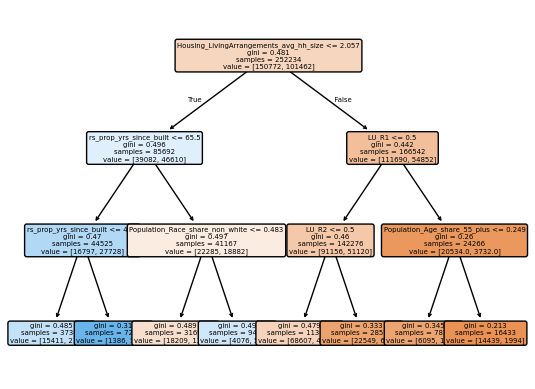

In [ ]:
sklearn.tree.plot_tree(treeclass, feature_names= X.columns, filled=True, fontsize=5, rounded=True)
import graphviz
# DOT data
dot_data = treeclass.export_graphviz(clf, out_file=None,
                                feature_names=X.columns,
                                class_names=iris.target_names,
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

In [6]:
rf = sklearn.ensemble.RandomForestClassifier()
rf.fit(Xtrain, ytrain)

RandomForestClassifier()

In [7]:
rf.score(Xtest, ytest)

0.7885630917077657